##**Maestría en Inteligencia Artificial Aplicada**
###**Curso: Inteligencia Artificial y Aprendizaje Automático**
####Tecnológico de Monterrey
####Prof Luis Eduardo Falcón Morales

### **Adtividad de la Semana 8**
####**Reducción de Dimensionalidad - Descomposición en Valores Singulares (SVD) y Sistemas de Recomendación**


**Esta Actividad deberás resolverla de manera individual.**

**Nombre y matrícula:**

*  Carlos Fernnado Del Castillo Rey
* A01796595
   


In [1]:
# Agrega aquí todas las librerías y paquetes adicionales que requieras.

import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

### **Liga de Datos de la UCI "Restaurant & consumer data".**
### **Descarga "RCdata.zip" y de ahí necesitaremos los archivos "rating_final.csv" y "geoplaces2.csv".**

https://archive.ics.uci.edu/dataset/232/restaurant+consumer+data

### **Puedes también usar la siguiente liga:**

https://www.kaggle.com/datasets/prajitdatta/movielens-100k-dataset

In [2]:
# Descarga los archivos de la página de la UCI a partir de los cuales generaremos
# nuestras matrices de utilidad.

data_rating = pd.read_csv("D:\\Mestria\\ML\\restaurant+consumer+data\\rating_final.csv", header='infer', sep=",")
data_geo = pd.read_csv("D:\Mestria\\ML\\restaurant+consumer+data\\geoplaces2.csv", header='infer',  encoding='latin-1')

print(data_rating.shape, data_geo.shape)


(1161, 5) (130, 21)


## **Ejercicio - 1**

### **Explica cuál es el propósito de usar el argumento "latin-1" al cargar el segundo archivo.**

++++++++ Inicia la sección de agregar texto: +++++++++++

Es un tipo de codificación de caracteres que soporta los alfabetos de Europa Occidental. Se usa cuando el archivo contiene caracteres especiales como:

Letras acentuadas (á, é, í, ó, ú)
Caracteres especiales en español y francés (ñ, ç, ü)
Símbolos especiales (€, £, ¿, ¡)

++++++++ Termina la sección de agregar texto. +++++++++++

## **Ejercicio - 2**

#### **Cada restaurante debe tener un nombre diferente:**

In [3]:
# Veamos la lista de restaurantes.
# Todos ellos son restaurantes ubicados en alguna ciudad del país de México:

data_geo['name'].values

array(['Kiku Cuernavaca', 'puesto de tacos', 'El Rincón de San Francisco',
       'little pizza Emilio Portes Gil', 'carnitas_mata',
       'Restaurant los Compadres', 'Taqueria EL amigo ', 'shi ro ie',
       'Pollo_Frito_Buenos_Aires', 'la Estrella de Dimas',
       'Restaurante 75', 'Abondance Restaurante Bar',
       'El angel Restaurante', 'Restaurante Pueblo Bonito',
       'Mcdonalds Parque Tangamanga', 'Tortas y hamburguesas el gordo',
       'Sirlone', 'rockabilly ', 'Unicols Pizza', 'TACOS EL GUERO',
       'Restaurant El Muladar de Calzada', 'La Posada del Virrey',
       'Restaurant and Bar and Clothesline Carlos N Charlies', 'KFC',
       'Giovannis', 'Restaurant Oriental Express', 'Mariscos Tia Licha',
       'cafe ambar', 'Restaurante la Gran Via', 'don burguers',
       'Restaurante y Pescaderia Tampico', 'Rincon del Bife',
       'La Fontana Pizza Restaurante and Cafe',
       'Restaurante la Estrella de Dima', 'El Rincon de San Francisco',
       'Preambulo Wifi Zone 

*   ### **Todos los restaurantes que aparecen en esta lista son negocios diferentes, en el sentido de que físicamente están ubicados en diferentes ciudades de México, aunque algunos pertenezcan a una franquicia, como Vips.**

*   ### **Para los fines de este ejercicio, estaremos considerando a todos los restaurantes como diferentes. Sin embargo, en el caso de Vips, existen tres restaurantes en esta lista capturados con los nombres: VIPS, Vips y vips. Que por sus coordenadas de latitud y longitud sabemos que están ubicados en SLP, Cuernavaca y cdVictoria. Se podrían cambiar los nombres agregando la ciudad, pero como se capturaron los nombres de manera diferente con minúsculas y mayúsculas, los dejaremos por el momento de esta manera.**

*   ### **Por el momento no estaremos haciendo las recomendaciones por el lugar donde se encuentran, sino solamente por la evaluación del restaurante y otras características que no tienen que ver con la ubicación.**

*   ### **Existen otras franquicias capturadas también de manera diferente, salvo el caso de 'Gorditas Dona Tota', en el cual dos de estos restaurantes que están ubicados en Cd.Victoria fueron registrados exactamente con el mismo nombre. Para que nuestro sistema de recomendación pueda diferenciarlos, deberás cambiar el nombre de uno de ellos como se te indica a continuación.**  

### **De los dos restaurantes registrados con el nombre de 'Gorditas Dona Tota', encuentra sus índices y cambia el que tiene el mayor índice en data_geo[name] al de  'Gorditas Dona Tota 2'.**

In [4]:
# Ejercicio-2

# ************* Inlcuye aquí tu código:*****************************


# Lista de índices de los registros con el nombre de 'Gorditas Dona Tota':
indices_Dona_Tota = data_geo[data_geo['name'] == 'Gorditas Dona Tota'].index

# Verificar si hay exactamente dos registros
if len(indices_Dona_Tota) == 2:
    # Encontrar el índice mayor
    max_index = max(indices_Dona_Tota)
    
    # Cambiar el nombre en el DataFrame
    data_geo.at[max_index, 'name'] = 'Gorditas Dona Tota 2'
    
    print(f"Se ha cambiado el nombre en el índice {max_index} a 'Gorditas Dona Tota 2'.")
else:
    print(f"Se encontraron {len(indices_Dona_Tota)} registros en lugar de 2.")



# *********** Aquí termina la sección de agregar código *************

print('Verificando el cambio de nombre:\n', data_geo.loc[indices_Dona_Tota, 'name'])

Se ha cambiado el nombre en el índice 118 a 'Gorditas Dona Tota 2'.
Verificando el cambio de nombre:
 89       Gorditas Dona Tota
118    Gorditas Dona Tota 2
Name: name, dtype: object


## **Ejercicio - 3**

In [5]:
# Al momento tenemos los siguientes DataFrames. Del primer archivo
# tenemos la evaluación general, la de la comida y la del servicio:

data_rating.head(3)

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2


In [6]:
# Y del segundo archivo obtenemos información diversa de cada restaurante:

data_geo.head(2).T

,0,1
placeID,134999,132825
latitude,18.915421,22.147392
longitude,-99.184871,-100.983092
the_geom_meter,0101000020957F000088568DE356715AC138C0A525FC46...,0101000020957F00001AD016568C4858C1243261274BA5...
name,Kiku Cuernavaca,puesto de tacos
address,Revolucion,esquina santos degollado y leon guzman
city,Cuernavaca,s.l.p.
state,Morelos,s.l.p.
country,Mexico,mexico
fax,?,?


### **De cada uno de estos archivos selecciona y combina las variables adecuadas para obtener un nuevo DataFrame cuyas columnas sean el ID de usuario (userID), el ID del restaurante (placeID), la calificación general (rating) y el nombre del restaurante (name). A este nuevo DataFrame llamarlo df_combinado.**

In [7]:
# Ejercicio 3:

# ************* Inlcuye aquí tu código:*****************************
# Verificar si hay valores duplicados en placeID en data_geo
duplicados_placeID = data_geo['placeID'].duplicated().sum()
print(f"Cantidad de placeID duplicados en data_geo: {duplicados_placeID}")

# Si hay duplicados, eliminarlos manteniendo solo la primera aparición
if duplicados_placeID > 0:
    data_geo = data_geo.drop_duplicates(subset=['placeID'])
    print("Duplicados eliminados.")

# Verificar si hay placeID en data_rating que no están en data_geo
placeID_no_coinciden = set(data_rating['placeID']).difference(set(data_geo['placeID']))
print(f"Cantidad de placeID en data_rating que no están en data_geo: {len(placeID_no_coinciden)}")


# Combinar los DataFrames usando placeID como clave
df_combinado = data_rating.merge(data_geo[['placeID', 'name']], on='placeID', how='left')[['userID', 'placeID', 'rating', 'name']]




# *********** Aquí termina la sección de agregar código *************


# Despleguemos la dimensión y los primeros renglones de este DataFrame:

print(df_combinado.shape)
df_combinado.head()

Cantidad de placeID duplicados en data_geo: 0
Cantidad de placeID en data_rating que no están en data_geo: 0
(1161, 4)


,userID,placeID,rating,name
0,U1077,135085,2,Tortas Locas Hipocampo
1,U1077,135038,2,Restaurant la Chalita
2,U1077,132825,2,puesto de tacos
3,U1077,135060,1,Restaurante Marisco Sam
4,U1068,135104,1,vips


## **Ejercicio - 4**

In [8]:
# Ejercicio 4:

#    Define la matriz de utilidad cuyos renglones sean los nombres de los
#    restaurantes, las columnas los IDs de los usuarios y las entradas la
#    evaluación general (rating). La llamaremos "UtMx_rating".


# ************* Inlcuye aquí tu código:*****************************
# Crear matriz de utilidad
UtMx_rating = df_combinado.pivot(index='name', columns='userID', values='rating')
UtMx_rating.fillna(0, inplace=True)

# Verificar coincidencias entre los nombres en UtMx_rating y data_geo
restaurantes_faltantes_en_geo = set(UtMx_rating.index).difference(set(data_geo['name']))
restaurantes_faltantes_en_utmx = set(data_geo['name']).difference(set(UtMx_rating.index))

print(f"Restaurantes en UtMx_rating que no están en data_geo: {len(restaurantes_faltantes_en_geo)}")
print(f"Restaurantes en data_geo que no están en UtMx_rating: {len(restaurantes_faltantes_en_utmx)}")

# *********** Aquí termina la sección de agregar código *************


print('Dimensión de la matriz de Utilidad:')
print('(restaurantes, usuarios) =', (UtMx_rating.shape))
UtMx_rating.head()

Restaurantes en UtMx_rating que no están en data_geo: 0
Restaurantes en data_geo que no están en UtMx_rating: 0
Dimensión de la matriz de Utilidad:
(restaurantes, usuarios) = (130, 138)


userID,U1001,U1002,U1003,U1004,U1005,U1006,U1007,U1008,U1009,U1010,...,U1129,U1130,U1131,U1132,U1133,U1134,U1135,U1136,U1137,U1138
name,,,,,,,,,,,,,,,,,,,,,
Abondance Restaurante Bar,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Arrachela Grill,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cabana Huasteca,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
Cafe Chaires,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Cafeteria cenidet,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### **Similaridades con la matriz obtenida de la Factorización SVD Truncada:**

*   ### **Aplicaremo la Factorización SVD con los 66 primeros valores singulares a la matriz de utilidad UtMx_rating.**

*   ### **El valor de 66 se seleccionó porque como verás, esta cantidad de valores singulares es suficiente para describir al menos el 95% de la varianza de la matriz de utilidad.**

*   ### **Recordemos que la factorización SVD de una matriz $A$ tiene la forma:** $A_{m\times n} = U_{m\times m}\Sigma_{m\times n}V_{n\times n}^T$

*   ### **Usaremos la función coseno como medida de similaridad**

*   ### **Buscaremos restaurantes similares al llamado  "tacos de barbacoa enfrente del Tec"**.

In [9]:
num_componentes=66  # componentes más significativas

# Obtengamos la matriz de factores latentes de los restaurantes:
SVD_rating = TruncatedSVD(n_components=num_componentes)  # inicializamos
mat_fact_lat_restaurantes = SVD_rating.fit_transform(UtMx_rating) # SVD truncada-ndarray

print('Dimensión Vectores latentes restaurantes:', mat_fact_lat_restaurantes.shape)
print('Dimensión Traspuesta Vectores latentes usuarios:', SVD_rating.components_.shape)

# Calculemos la variabilidad acumulada de las componentes utilizadas:
print('\nVariabilidad acumulada de las componentes utilizadas: %.3f' % SVD_rating.explained_variance_ratio_[0:num_componentes].sum())

# matriz de similaridad
sim_matrix = cosine_similarity(mat_fact_lat_restaurantes)

# Restaurante de referencia:
restaurante_de_referencia = "tacos de barbacoa enfrente del Tec"
nombres_rest = UtMx_rating.T.columns  # lista de los nombres de los restaurantes.
idx_rest = list(nombres_rest).index(restaurante_de_referencia) # índice del restaurante de referencia.
sim_vector = sim_matrix[idx_rest] # Vector de similaridad del restaurante de referencia contra todos.

# Buscando las similaridades positivas:
idx = (sim_vector>0)
mejores_sim_rate = list()
for i in range(len(nombres_rest[idx])):
  mejores_sim_rate.append((sim_vector[idx][i], nombres_rest[idx][i]))

print('\nTotal de similaridades positivas encontradas:', len(mejores_sim_rate))

# Las ordenamos de mayor a menor relevancia:
mejores_sim_rate_ordenadas = sorted(mejores_sim_rate, key=lambda x:x[0], reverse=True)

print('\nMejores recomendaciones con base al restaurante: \"%s\":' % restaurante_de_referencia)
mejores_sim_rate_ordenadas[1:11]   # omitimos el primero que es el mismo restaurante de referencia


Dimensión Vectores latentes restaurantes: (130, 66)
Dimensión Traspuesta Vectores latentes usuarios: (66, 138)

Variabilidad acumulada de las componentes utilizadas: 0.952

Total de similaridades positivas encontradas: 72

Mejores recomendaciones con base al restaurante: "tacos de barbacoa enfrente del Tec":


[(0.936897069100168, 'vips'),
 (0.9344813593796527, 'little pizza Emilio Portes Gil'),
 (0.9269696755652471, 'tacos abi'),
 (0.5300566030805269, 'Carreton de Flautas y Migadas'),
 (0.4973518204040439, 'puesto de gorditas'),
 (0.4773852599138583, 'Taqueria EL amigo '),
 (0.3649244994762572, 'carnitas_mata'),
 (0.26222168126086964, 'Little Cesarz'),
 (0.2337543884136952, 'Gorditas Dona Tota 2'),
 (0.1846628873060795, 'carnitas mata calle Emilio Portes Gil')]

## **Ejercicio - 5**

### **Sistema Híbrido**

### **Utilicemos ahora un sistema híbrido, el cual consistirá en conjuntar la matriz de "factores_latentes_restaurantes" (que es un ndarray) obtenida previamente, con la matriz de factores adicionales (que también será un ndarray) formada por las columnas One-Hot-Encoder de los factores 'dress_code', 'accessibility', 'price' y 'franchise' del DataFrame data_geo.**

### **Por el momento no requerimos que la matriz híbrida sea un DataFrame, con que sea un arreglo de NumPy, ndarray, será suficiente.**

### **Los renglones de la matriz híbrida siguen representando a cada restaurante, pero ahora con la información de los vectores latentes de la factorización SVD, más los vectores OneHotEncoding de los nuevos factores que se incluyeron.**



In [10]:
# Ejercicio 5:

# Define el DataFrame "df_fact_adicionales" formada por los factores 'dress_code',
# 'accessibility', 'price' y 'franchise'.
# Después generar la matriz (ndarray), "mat_fact_adicionales_ohe", que se obtiene
# al tranformar las columnas (variables categóricas nominales) de "df_fact_adicionales"
# mediante OneHotEncoding.
# Finalmente conjuntar horizontalmente la matriz "mat_fact_lat_restaurantes"
# con "mat_fact_adicionales_ohe" para obtener la "matriz_hibrida" (ndarray).
# Toma en cuenta que "matriz_hibrida" estará formada por las columnas de "mat_fact_lat_restaurantes"
# seguida por las columnas de "mat_fact_adicionales_ohe".


# ************* Inlcuye aquí tu código:*****************************
# Reordenar data_geo para coincidir con el índice de UtMx_rating
data_geo = data_geo.set_index("name").loc[UtMx_rating.index].reset_index()

# Verificar dimensiones antes de aplicar One-Hot Encoding
print(f"Dimensiones alineadas: data_geo={data_geo.shape}, UtMx_rating={UtMx_rating.shape}")


# Seleccionar las columnas deseadas
df_fact_adicionales = data_geo[['dress_code', 'accessibility', 'price', 'franchise']]

# Aplicar One-Hot Encoding a las variables categóricas
ohe = OneHotEncoder(drop='first', sparse_output=False)  # Evita colinealidad con drop='first'
mat_fact_adicionales_ohe = ohe.fit_transform(df_fact_adicionales)

# Convertir la matriz de factores latentes a ndarray si no lo es
mat_fact_lat_restaurantes = np.array(mat_fact_lat_restaurantes)

# Concatenar horizontalmente las matrices para formar "matriz_hibrida"
matriz_hibrida = np.hstack((mat_fact_lat_restaurantes, mat_fact_adicionales_ohe))




# *********** Aquí termina la sección de agregar código *************


print('Dimensión de la matriz híbrida:')
matriz_hibrida.shape

Dimensiones alineadas: data_geo=(130, 21), UtMx_rating=(130, 138)
Dimensión de la matriz híbrida:


(130, 73)

In [11]:
# Recordemos que "restaurante_de_referencia" es "tacos de barbacoa enfrente del Tec".
# Obtener el índice del restaurante
idx = data_geo[data_geo['name'] == restaurante_de_referencia].index[0]

print('Restaurante de referencia:', restaurante_de_referencia)
print('Índice del restaurante de referencia:', idx)

Restaurante de referencia: tacos de barbacoa enfrente del Tec
Índice del restaurante de referencia: 125


## **Ejercicio - 6:**

### **Una vez que tenemos la matriz híbrida, con dicha matriz deberás obtener las similitudes (con respecto a la función coseno) del restaurante de referencia con relación a todos los restaurantes, ordenarlos de mayor a menor con respecto a la similitud del coseno y desplegar los primeros 10 de mayor similitud (sin incluir al restaurante de referencia mismo).**

In [12]:
# Ejercicio 6

# ************* Inlcuye aquí tu código:*****************************
# Obtener el nombre del restaurante de referencia
restaurante_referencia_nombre = data_geo.iloc[idx]['name']
print(restaurante_referencia_nombre)

# Calcular la similitud del coseno entre el restaurante de referencia y todos los demás
similitudes = cosine_similarity(matriz_hibrida[idx].reshape(1, -1), matriz_hibrida)[0]

# Ordenar de mayor a menor, excluyendo el restaurante de referencia mismo
indices_ordenados = np.argsort(similitudes)[::-1]  # Orden descendente
indices_ordenados = indices_ordenados[indices_ordenados != idx]  # Excluir referencia

# Seleccionar los primeros 10 restaurantes más similares
top_10_similares = indices_ordenados[:10]

# Obtener nombres de los restaurantes más similares
top_10_restaurantes = [(i, data_geo.iloc[i]['name'], similitudes[i]) for i in top_10_similares]

# Mostrar resultados en un DataFrame
df_top_10 = pd.DataFrame(top_10_restaurantes, columns=['Índice', 'Nombre', 'Similitud'])


df_top_10.head(10)



# *********** Aquí termina la sección de agregar código *************

tacos de barbacoa enfrente del Tec


,Índice,Nombre,Similitud
0,124,tacos abi,0.961382
1,115,little pizza Emilio Portes Gil,0.877863
2,129,vips,0.726562
3,119,puesto de gorditas,0.665972
4,8,Carreton de Flautas y Migadas,0.663563
5,7,Carnitas Mata Calle 16 de Septiembre,0.636618
6,93,Taqueria EL amigo,0.502378
7,99,cafe ambar,0.501892
8,49,Pollo_Frito_Buenos_Aires,0.496628
9,28,Hamburguesas saul,0.488703


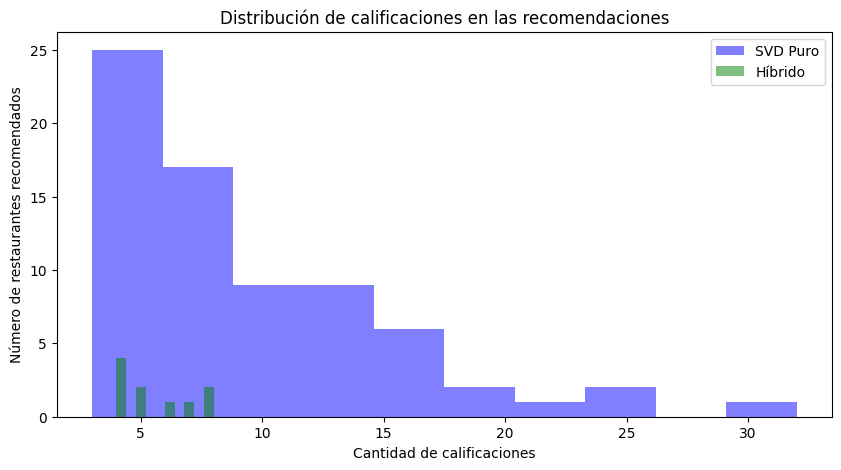

In [13]:
#Revisar si existe EL SESGO DE USAR SVD VS HIBRIDO RN BASE A LA CANTIDAD DE CALIFICACIONES
# Contar el número de calificaciones que ha recibido cada restaurante
calificaciones_por_restaurante = df_combinado.groupby("name")["rating"].count()

# Añadir esta información a los restaurantes recomendados por SVD
resultados_svd_df = pd.DataFrame(mejores_sim_rate, columns=['similitud', 'nombre'])
resultados_svd_df["calificaciones_totales"] = resultados_svd_df["nombre"].map(calificaciones_por_restaurante)

# Ordenar por similitud
resultados_svd_df = resultados_svd_df.sort_values(by="similitud", ascending=False)

# Obtener las calificaciones de los restaurantes recomendados en ambos modelos
calificaciones_svd = resultados_svd_df["calificaciones_totales"]
calificaciones_hibrido = df_top_10["Nombre"].map(calificaciones_por_restaurante)

# Crear histograma
plt.figure(figsize=(10,5))
plt.hist(calificaciones_svd, bins=10, alpha=0.5, label="SVD Puro", color="blue")
plt.hist(calificaciones_hibrido, bins=10, alpha=0.5, label="Híbrido", color="green")
plt.xlabel("Cantidad de calificaciones")
plt.ylabel("Número de restaurantes recomendados")
plt.title("Distribución de calificaciones en las recomendaciones")
plt.legend()
plt.show()


## **Ejercicio - 7**

### **Incluye tus comentarios y conclusiones de la actividad. En particular comenta las diferencias que encuentras entre un sistema de recomendación basado solamente en la factorización SVD y uno híbrido.**

++++++++ Inicia la sección de agregar texto: +++++++++++


Factorización SVD 

La factorización SVD se basa en la matriz de utilidad de calificaciones de los usuarios a los restaurantes.
Su ventaja principal es que reduce la dimensionalidad, permitiendo descubrir patrones latentes en las preferencias de los usuarios.
Sin embargo, tiene problemas con el "cold start", ya que los restaurantes sin suficientes calificaciones o los nuevos usuarios no pueden ser recomendados correctamente.
No considera atributos adicionales como price, franchise, accessibility, etc.
Puede haber sesgo hacia restaurantes con más calificaciones, incluso si son menos relevantes en atributos específicos.


Sistema Híbrido (Factorización + Información Adicional)

Incorporamos variables adicionales como dress_code, accessibility, price y franchise mediante One-Hot Encoding, combinándolas con los factores latentes obtenidos de SVD.
Este enfoque permite que los restaurantes con poca o ninguna calificación en la matriz de utilidad puedan ser recomendados, ya que tienen atributos que pueden ser comparados con otros restaurantes similares.
Mejora la capacidad de generalización del modelo y mitiga el problema del cold start.
Se basa en factores latentes (SVD) + atributos adicionales (One-Hot Encoding).
Ejemplo: cafe ambar y Pollo_Frito_Buenos_Aires no aparecían en SVD puro, pero en el híbrido sí.
Evita que la recomendación sea dominada solo por restaurantes altamente calificados.


Un sistema basado solo en SVD es eficiente cuando se tienen suficientes datos de calificaciones y los usuarios han interactuado con muchos restaurantes.
El sistema híbrido es más robusto, ya que combina información de calificaciones con atributos explícitos de los restaurantes, permitiendo hacer recomendaciones más acertadas en escenarios con datos escasos.
En aplicaciones reales, los sistemas híbridos suelen ser más efectivos, ya que combinan lo mejor del filtrado colaborativo y del filtrado basado en contenido.



++++++++ Termina la sección de agregar texto. +++++++++++

>> **Fin de la Actividad de Sistemas de Recomendación**